Probabilidades reales de moneda por casilla
  [0.1 0.2 0.1 0.3 0.2 0.1 0.5 0.8 0.1]
Número de veces que se eligió cada casilla
  [ 33.  38.  27.  63.  40.  33. 103. 627.  36.]
Q(a) (Recompensa media estimada) de las casillas
  [0.0909 0.1579 0.     0.3492 0.175  0.0909 0.4951 0.8054 0.1389]
Recompensa total acumulada: 602


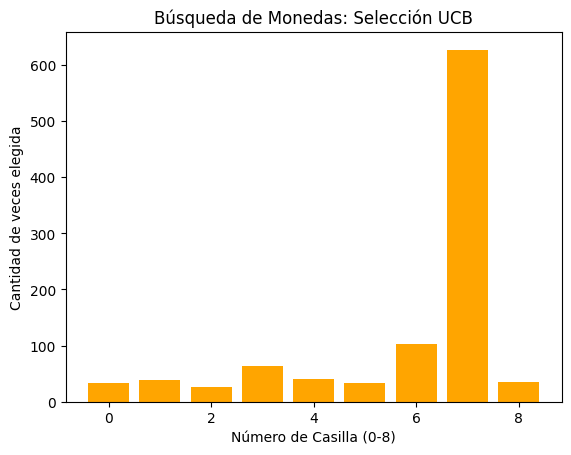

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

def gen_casillas_tablero():
    """
    Función que devuelve una lista de probabilidades de encontrar una moneda
    en cada una de las 9 casillas (simulando un tablero 3x3).
    """
    casillas = [0.1, 0.1, 0.2, 0.3, 0.8, 0.1, 0.5, 0.2, 0.1]
    random.shuffle(casillas)
    return casillas

def juego_monedas_ucb(num_games=1000, c=2.0, verbose=False):

    casillas = gen_casillas_tablero()
    total_reward = 0
    acum_reward_casilla = np.zeros(len(casillas))  # numerador
    num_selected_casilla = np.zeros(len(casillas)) # denominador
    q_casillas = np.zeros(len(casillas))           # Q(a)

    if verbose:
        print("Distribución Inicial del Tablero (Probabilidades)\n  {}".format(casillas))

    # Empezamos el juego en 1 para evitar errores de división por cero en log(t)
    for game in range(1, num_games + 1):

        # Hago una copia de los Q(a)
        old_q_casillas = q_casillas.copy()

        # Identificamos si hay casillas completamente "nuevas" (no visitadas)
        unvisited = np.where(num_selected_casilla == 0)[0]

        if len(unvisited) > 0:
            # EXPLORACIÓN INICIAL: Forzamos a que pruebe las nuevas casillas al menos una vez
            casilla = np.random.choice(unvisited)
        else:
            # SELECCIÓN CON INTERVALO DE CONFIANZA (UCB)
            # Balancea la "Explotación" de Q(a) y la "Exploración" del término de incertidumbre
            ucb_values = q_casillas + c * np.sqrt(np.log(game) / num_selected_casilla)
            casilla = np.argmax(ucb_values)

        # Obtengo el reward (1 si encuentra la moneda, 0 si no)
        reward = 1 if (np.random.random() < casillas[casilla]) else 0

        # Actualizo reward total
        total_reward += reward

        # Actualizo valor (Q) de la casilla elegida
        acum_reward_casilla[casilla] += reward
        num_selected_casilla[casilla] += 1
        q_casillas[casilla] = acum_reward_casilla[casilla] / num_selected_casilla[casilla]

        if verbose and game <= 10: # Para no saturar, se muestran solo los 10 primeros juegos
            print("\nGAME {game}\n  Old Q_Casillas = {old_q_casillas}\n  Casilla Seleccionada = {casilla} \
                  \n  Reward = {reward}\n  Q_Casillas = {q_casillas}"
                  .format(game=game, old_q_casillas=old_q_casillas, casilla=casilla,
                          reward=reward, q_casillas=np.round(q_casillas, 4)))

    return casillas, total_reward, q_casillas, num_selected_casilla

# Ejecución del Agente y Visualización

# Parámetro de exploración 'c' configurado en 2.0
casillas, total_reward, q_casillas, num_selected_casilla = juego_monedas_ucb(num_games=1000, c=2.0, verbose=False)

print("Probabilidades reales de moneda por casilla\n  {}".format(np.array(casillas)))
print("Número de veces que se eligió cada casilla\n  {}".format(num_selected_casilla))
print("Q(a) (Recompensa media estimada) de las casillas\n  {}".format(np.round(q_casillas, 4)))
print("Recompensa total acumulada: {}".format(total_reward))

# Mostramos en una gráfica de barras el número de veces que elegimos cada casilla
plt.title('Búsqueda de Monedas: Selección UCB')
plt.bar(range(0, len(casillas)), num_selected_casilla, color='orange')
plt.xlabel('Número de Casilla (0-8)')
plt.ylabel('Cantidad de veces elegida')
plt.show()